### CV Evaluator

In [312]:
import openai
# Core
import os
import re
import json
import io
import logging
import pathlib
import sqlite3
from typing import TypedDict, List

# I/O and environment
from dotenv import load_dotenv, find_dotenv
from PyPDF2 import PdfReader
from IPython.display import display, Markdown, Image

# LangChain
from langchain_classic.chains import RetrievalQA, LLMChain, StuffDocumentsChain
from langchain_core.prompts import PromptTemplate
from langchain_community.document_loaders import TextLoader, PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# Pinecone
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore

# LangGraph
from langgraph.graph import START, StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver

In [313]:
# Load enviroment
load_dotenv(find_dotenv())
memory = InMemorySaver()
openai_api_key = os.getenv("OPENAI_API_KEY")
pinecone_api_key = os.getenv('PINECONE')

# Set the api keys
openai.api_key =openai_api_key
client = openai.OpenAI()

MODEL_NAME = "gpt-4o-mini"

In [314]:
# Initialize OpenAIEmbedding from Langchain
embeddings = OpenAIEmbeddings(openai_api_key=openai_api_key)

pc = Pinecone(api_key=pinecone_api_key)

index = pc.Index("agentrag")

# Initialize Pinecone using Langchaing and sending the embedding
pinecone_vectorstore = PineconeVectorStore(index=index, embedding=embeddings)

In [315]:
## Load the files
def load_pdf_texts_from_folder(folder_path: str):
    all_docs = []
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(".pdf"):
            pdf_path = os.path.join(folder_path, filename)
            loader = PyPDFLoader(pdf_path)
            pages = loader.load()
            all_docs.extend(pages)
            
    return all_docs


folder_path = pathlib.Path().resolve()
docs_in_folder = load_pdf_texts_from_folder(folder_path)
print(docs_in_folder)
texts = [doc.page_content for doc in docs_in_folder]
print(texts)

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2025-12-07T20:50:42+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2025-12-07T20:50:42+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'F:\\IA\\NLPII\\Ejercicios\\tp3\\ai_bigtech_cv.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='Emily R. Stanton\nPrincipal AI Engineer & LLM Systems Architect\nContact Information\nEmail: emily.stanton.ai@example.com\nPhone: +1 (415) 555-9023\nLocation: Seattle, WA, USA\nLinkedIn: linkedin.com/in/emilystanton-LLM\nGitHub: github.com/emily-ml\nProfessional Summary\nPrincipal AI Engineer with 10+ years of experience designing large-scale AI and RAG systems at major\ntechnology companies including Google, Meta, and Microsoft. Expert in LLM architecture, retrieval\nsystems, distributed training pipelines, and high-performance inference. Proven success leading\n

In [316]:

doc_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100, separators=["\n\n", "\n", ".", " "])
documents_for_evaluation = doc_splitter.split_documents(docs_in_folder)

In [317]:
# Index document definition
def index_documents():
    ids = [f"cv_{i+1}" for i in range(len(documents_for_evaluation))]
    pinecone_vectorstore.add_documents(
        documents=documents_for_evaluation,
        ids=ids
    )

In [318]:
# Instance index_documents
index_documents()

In [319]:
# The TypeDdict is imported from the typing module for defining a type of dictionary with specific values keys and typed values.
from typing_extensions import Annotated
class AgentState(TypedDict):
    # High-level instructions or evaluation goal
    task:str
    # Dynamic question or CV-specific request
    question: str
    # Auto-generated plan for evaluation flow
    plan:str
    # Node routing / decision value
    decider: str
    # Retrieved context (RAG)
    context: Annotated[List[Document], "accumulate"]
    # Raw text chunks extracted from PDFs or CV inputs
    content: Annotated[List[str], "accumulate"]
    # Final structured answer
    answer: str
    # Routing fields
    next: str
    detected_name: str
    routing_answer: str

In [320]:
ChatOpenAI.api_key = os.getenv("OPENAI_API_KEY")
model = ChatOpenAI(
    model=MODEL_NAME,
    temperature=0,
    max_retries=2,
    timeout=60
)

In [321]:
GENERATE_PROMPT = """
You are an expert assistant specialized in CV and résumé analysis.

**IMPORTANT INSTRUCTIONS**
- Use ONLY the information provided in the context.
- If the context does not contain the necessary information, explicitly answer:
  "The information is not available in the context."
- Do NOT invent or infer details that are not grounded in the context.
- Provide answers that are precise, concise, and well-structured.

---

**Question:**  
{question}

---

**Context (retrieved fragments):**
{docs_content}

---

**Answer:**
""".strip()

In [322]:
PLAN_PROMPT = """
You are an AI assistant specialized in CV analysis. Your task is to generate a high-level evaluation plan strictly based on the provided CV text.

RAG SAFETY RULES:
- Use ONLY the text provided in {source}.
- Do NOT infer or assume any information not explicitly present.
- If the content is missing or incomplete, state that the information is unavailable.

YOUR TASKS:
1. Provide a concise summary of the document’s main characteristics (experience, skills, education, etc.).
2. Create a structured evaluation outline based SOLELY on the available content.
3. If the CV text is empty or unreadable, respond: "No valid CV content available."

CONSTRAINTS:
- Maximum length: {word_limit} words.
- Maintain factual grounding to the supplied context.

CV Content Source:
{source}
"""

In [323]:
DECIDER_PROMPT = """
You are a routing agent that determines which evaluator should process a CV.
You must analyze the full text of the CV and extract the following:

- Candidate full name
- Seniority
- Primary role
- Technologies and skills
- Languages
- Region / country
- Any other identifying information relevant for routing

====================
ROUTING RULES
====================

1. NAME-BASED ROUTING (highest priority)
----------------------------------------
Send to "Evaluator1" if the candidate's name or surname matches ANY of:

- Known AI-focused candidate list: {preferred_ai_names}
- Known internal VIP list: {vip_names}
- Surname patterns ending with: {surname_patterns_ai}

Send to "Evaluator2" if:

- Candidate's name matches the general engineering list: {preferred_eng_names}
- Surname patterns ending with: {surname_patterns_eng}

If no name rule matches → fallback to technical rules.

2. TECHNICAL ROUTING (fallback rules)
--------------------------------------

Send to "Evaluator1" when AT LEAST ONE is true:
- Seniority: Senior, Lead, Principal, Staff
- Role: AI Engineer, ML Engineer, Data Scientist, MLOps, Research Engineer
- Technologies include: PyTorch, TensorFlow, JAX, Transformers, LangChain, VectorDBs, RAG, LLM finetuning
- Region: LATAM or Europe
- English Level: B2, C1, C2

Send to "Evaluator2" when ANY is true:
- Seniority: Intern, Junior, Mid
- Role: Backend, Full-stack, DevOps, QA, Mobile, SysAdmin
- Technologies: Node.js, React, Java, Go, PHP, Ruby, Swift, Flutter
- Region: USA, Canada, Asia
- English level below B2

3. If both (1) and (2) are ambiguous:
- Prefer Evaluator1 for AI-related terms
- Prefer Evaluator2 for general software engineering

====================
OUTPUT FORMAT
====================

Return ONLY the following JSON:

{{
  "next": "Evaluator1" | "Evaluator2",
  "detected_name": "<string>",
  "detected_seniority": "<string>",
  "detected_role": "<string>",
  "detected_region": "<string>",
  "detected_languages": ["..."],
  "detected_technologies": ["..."],
  "reason": "<short explanation citing the rules applied>"
}}
"""

In [324]:
LLM_PROMPT_USER1 = """
You are an AI agent that transforms a user's goal into search queries for retrieving relevant CV information.

RAG SAFETY RULES:
- Use ONLY the content found in the provided context.
- Do NOT invent skills, experience, or personal details.
- If information is missing, NEVER guess. Report that it is missing.

IDENTITY VERIFICATION:
- Proceed ONLY if the candidate name "{candidate_name}" appears EXACTLY as written in the context.
- If the candidate name does NOT appear, respond ONLY with:

{{
  "error": "Candidate {candidate_name} is not mentioned in the provided context."
}}

IF NAME IS PRESENT:
- Generate 2–5 short search queries that could retrieve relevant evidence about the candidate's skills, experience, or achievements.

RESPONSE FORMAT (strict):
{{
  "queries": ["query 1", "query 2", ...]
}}

Context:
{context}
"""

In [325]:
LLM_PROMPT_USER2 = """
You are an AI assistant that generates targeted search queries to evaluate a candidate's CV.

RAG SAFETY RULES:
- Use ONLY information that exists in the provided context.
- NEVER infer or fabricate any detail.
- If information is missing or unclear, do not guess.

IDENTITY REQUIREMENT:
- You may proceed ONLY if the candidate "{candidate_name}" appears explicitly in the context.
- If NOT present, respond EXACTLY with:

{{
  "error": "I cannot provide the evaluation because {candidate_name} is not the candidate mentioned in the document."
}}

IF NAME IS PRESENT:
- Generate 2–5 short, factual, context-aligned search queries.
- Queries must be general enough to retrieve information, but not assume information exists.
- Do not embed new facts about the candidate.

STRICT JSON FORMAT:
{{
  "queries": [
    "What skills does {candidate_name} list?",
    "What job roles has {candidate_name} held?",
    "What relevant experience does {candidate_name} mention?",
    "What certifications or courses does {candidate_name} include?",
    "What industries or domains does {candidate_name} reference?"
  ]
}}

Context:
{context}
"""

In [326]:
from pydantic import BaseModel
from typing import List

class Queries(BaseModel):
    queries: List[str]

In [327]:
def plan_node(state: AgentState):
    # Get CV context from retriever
    context = state.get("context", [])
    cv_text = "\n\n".join(str(c) for c in context) if context else "No CV content"
    
    # Format the prompt with actual values
    prompt_formatted = PLAN_PROMPT.format(
        source=cv_text,
        word_limit=200
    )
    
    messages = [
        SystemMessage(content=prompt_formatted),
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}

In [328]:
def decider_node(state: AgentState):
    """
    LLM-based CV routing using DECIDER_PROMPT with robust JSON handling
    """
    context = state.get("context", [])
    cv_text = "\n\n".join(str(c) for c in context) if context else ""
    
    if not cv_text:
        print("⚠️ No CV content available")
        return {"next": "Evaluator1", "decider": "Evaluator1"}
    
    # =====================================================
    # Define routing configuration
    # =====================================================
    PREFERRED_AI_NAMES = [
        "Emily R. Stanton", "Emily Stanton",
        "Lucia Gomez", "Wei Zhang", "Maria Rodriguez"
    ]
    
    PREFERRED_ENG_NAMES = [
        "John A. Mercer", "John Mercer",
        "Emily Clark", "Michael Johnson", "Sarah Williams"
    ]
    
    VIP_NAMES = [
        "Elon Musk", "Sam Altman", "Yann LeCun", 
        "Geoffrey Hinton", "Andrew Ng"
    ]
    
    SURNAME_PATTERNS_AI = ["-ez", "-an", "-ov", "-ski", "-ian"]
    SURNAME_PATTERNS_ENG = ["-son", "-ton", "-ford", "-ley", "-worth"]
    
    # =====================================================
    # Format DECIDER_PROMPT with routing lists
    # =====================================================
    try:
        formatted_prompt = DECIDER_PROMPT.format(
            preferred_ai_names=", ".join(PREFERRED_AI_NAMES),
            preferred_eng_names=", ".join(PREFERRED_ENG_NAMES),
            vip_names=", ".join(VIP_NAMES),
            surname_patterns_ai=", ".join(SURNAME_PATTERNS_AI),
            surname_patterns_eng=", ".join(SURNAME_PATTERNS_ENG)
        )
        
        # Add extra JSON instruction
        formatted_prompt += "\n\n**CRITICAL**: Return ONLY valid JSON. No explanations, no markdown, just the JSON object."
        
    except KeyError as e:
        print(f"❌ Prompt formatting failed: {e}")
        return {"next": "Evaluator1", "decider": "Evaluator1"}
    
    # =====================================================
    # Invoke LLM with JSON mode
    # =====================================================
    messages = [
        SystemMessage(content=formatted_prompt),
        HumanMessage(content=f"Analyze and route this CV:\n\n{cv_text[:3000]}")
    ]
    
    # Try with JSON response format first
    try:
        json_model = ChatOpenAI(
            model=MODEL_NAME,
            temperature=0,
            max_retries=2,
            timeout=60,
            model_kwargs={"response_format": {"type": "json_object"}}
        )
        response = json_model.invoke(messages)
        raw_response = response.content.strip()
        print(f"🤖 LLM response ({len(raw_response)} chars)")
        
    except Exception as e:
        print(f"⚠️ JSON mode unavailable: {e}")
        print("   Trying standard mode...")
        
        try:
            response = model.invoke(messages)
            raw_response = response.content.strip()
        except Exception as e2:
            print(f"❌ LLM call failed: {e2}")
            # Use fallback routing
            return _fallback_routing(cv_text)
    
    # =====================================================
    # Parse JSON using multiple strategies
    # =====================================================
    routing_decision = _parse_json_response(raw_response)
    
    if not routing_decision:
        print("❌ All JSON parsing strategies failed")
        return _fallback_routing(cv_text)
    
    # =====================================================
    # Extract and validate routing decision
    # =====================================================
    next_node = routing_decision.get("next", "Evaluator1")
    detected_name = routing_decision.get("detected_name", "Unknown")
    detected_role = routing_decision.get("detected_role", "Unknown")
    reason = routing_decision.get("reason", "No reason provided")
    
    # Validate next node
    if next_node not in ["Evaluator1", "Evaluator2"]:
        print(f"⚠️ Invalid routing value '{next_node}', defaulting to Evaluator1")
        next_node = "Evaluator1"
    
    # Log results
    print(f"👤 Detected: {detected_name}")
    print(f"💼 Role: {detected_role}")
    print(f"🔀 Routing to: {next_node}")
    print(f"📋 Reason: {reason}")
    
    return {
        "next": next_node,
        "decider": next_node,
        "detected_name": detected_name,
        "routing_reason": reason
    }


def _parse_json_response(raw_response: str) -> dict:
    """
    Try multiple strategies to extract JSON from LLM response
    Returns None if all strategies fail
    """
    if not raw_response:
        return None
    
    # Strategy 1: Direct JSON parsing
    try:
        result = json.loads(raw_response)
        print("✅ JSON parsed (direct)")
        return result
    except json.JSONDecodeError:
        pass
    
    # Strategy 2: Extract from markdown code block
    json_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', raw_response, re.DOTALL)
    if json_match:
        try:
            result = json.loads(json_match.group(1))
            print("✅ JSON extracted (code block)")
            return result
        except:
            pass
    
    # Strategy 3: Find JSON object with regex
    json_match = re.search(r'\{[^{]*"next"[^}]*\}', raw_response, re.DOTALL)
    if json_match:
        try:
            result = json.loads(json_match.group(0))
            print("✅ JSON extracted (regex)")
            return result
        except:
            pass
    
    # Strategy 4: Try to find and clean JSON
    # Remove everything before first { and after last }
    start_idx = raw_response.find('{')
    end_idx = raw_response.rfind('}')
    
    if start_idx != -1 and end_idx != -1 and start_idx < end_idx:
        json_candidate = raw_response[start_idx:end_idx+1]
        try:
            result = json.loads(json_candidate)
            print("✅ JSON extracted (cleaned)")
            return result
        except:
            pass
    
    print("❌ All JSON extraction strategies failed")
    return None


def _fallback_routing(cv_text: str) -> dict:
    """
    Keyword-based fallback routing when LLM fails
    """
    print("⚠️ Using keyword-based fallback routing")
    
    cv_lower = cv_text.lower()
    
    # Extract candidate name
    name_match = re.search(r'^([A-Z][a-z]+(?:\s+[A-Z]\.?\s*)?[A-Z][a-z]+)', cv_text, re.MULTILINE)
    candidate_name = name_match.group(1) if name_match else "Unknown"
    
    # Score based on keywords
    ai_keywords = [
        "pytorch", "tensorflow", "jax", "llm", "rag", "transformers",
        "machine learning", "deep learning", "ai engineer", "ml engineer",
        "principal", "senior ai", "lead ml", "data scientist"
    ]
    
    gen_keywords = [
        "react", "node.js", "angular", "java developer", "php", "ruby",
        "backend", "frontend", "full stack", "mobile", "devops",
        "junior", "intern", "mid-level"
    ]
    
    ai_score = sum(1 for kw in ai_keywords if kw in cv_lower)
    gen_score = sum(1 for kw in gen_keywords if kw in cv_lower)
    
    if ai_score > gen_score:
        next_node = "Evaluator1"
        reason = f"Fallback: AI keywords ({ai_score}) > General ({gen_score})"
    else:
        next_node = "Evaluator2"
        reason = f"Fallback: General keywords ({gen_score}) >= AI ({ai_score})"
    
    print(f"🔀 Fallback routing to: {next_node}")
    print(f"📋 Reason: {reason}")
    
    return {
        "next": next_node,
        "decider": next_node,
        "detected_name": candidate_name,
        "routing_reason": reason
    }

In [329]:
def retriever(state: AgentState):
    """
    Use LLM to extract the best search query from the task
    """
    task = state.get("task", "")
    
    # Ask LLM to extract search terms from the task
    extraction_prompt = f"""
Given this evaluation task, extract 3-5 short keywords or phrases that would be most effective 
for searching a CV database. Return ONLY the search terms, comma-separated.

Task: {task[:500]}

Search terms:"""
    
    try:
        response = model.invoke(extraction_prompt)
        search_query = response.content.strip()
        print(f"🤖 LLM extracted query: '{search_query}'")
    except:
        search_query = "professional CV skills experience"
        print(f"⚠️ Using fallback query: '{search_query}'")
    
    # Retrieve using LLM-extracted query
    retr = pinecone_vectorstore.as_retriever(
        search_type="similarity",
        search_kwargs={"k": 10}
    )
    
    docs = retr.invoke(search_query) or []
    context = [d.page_content for d in docs if hasattr(d, "page_content")]
    
    print(f"✅ Retrieved {len(context)} chunks")
    if context:
        print(f"📄 Sample: {context[0][:150]}...")
    
    return {
        "context": context,
        "content": context[:],
        "query": search_query
    }

In [330]:
def generate(state: AgentState):
    context_docs = state.get("context", [])
    content_chunks = state.get("content", [])

    # Convert any Document objects → text
    if context_docs:
        docs_content = "\n\n".join(
            d.page_content if hasattr(d, "page_content") else str(d)
            for d in context_docs
        )
    elif content_chunks:
        docs_content = "\n\n".join(str(chunk) for chunk in content_chunks)
    else:
        return {"answer": "No context available to generate a response."}

    # Get the question
    question = (
        state.get("question")
        or state.get("task")
        or "Describe the main characteristics of the resumes."
    )

    # Format the prompt with actual values
    prompt = GENERATE_PROMPT.format(question=question, docs_content=docs_content)

    # Invoke the model
    try:
        response = model.invoke(prompt)
        return {"answer": response.content}
    except Exception as e:
        return {"answer": f"Error invoking model: {str(e)}"}

In [331]:
def llm_user1_node(state: AgentState):
    # Get context and extract candidate info
    context = state.get("context", [])
    context_text = "\n\n".join(str(c) for c in context)
    candidate_name = "the candidate"  # Or extract from context if needed
    
    # Format the prompt with actual values
    try:
        formatted_prompt = LLM_PROMPT_USER1.format(
            candidate_name=candidate_name,
            context=context_text
        )
    except KeyError as e:
        print(f"❌ Prompt formatting error: {e}")
        return {"content": [], "error": f"Prompt format error: {e}"}
    
    structured_llm = model.with_structured_output(Queries)
    messages = [
        SystemMessage(content=formatted_prompt),
        HumanMessage(content=state.get('task', ''))
    ]

    try:
        queries = structured_llm.invoke(messages)
        print("✅ Evaluator1 Queries:", queries)
    except Exception as e:
        return {"content": [], "error": f"Failed to generate queries: {e}"}

    if not queries or not getattr(queries, "queries", None):
        return {"content": [], "error": "No queries generated"}

    llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=pinecone_vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3}),
        return_source_documents=True 
    )

    content = []
    for q in queries.queries:
        if not isinstance(q, str):
            continue
        result = qa_chain.invoke({"query": q})
        print(f"📄 Answer: {result['result']}")
        content.append(result["result"])
       
    return {"content": content}

In [332]:
def llm_user2_node(state: AgentState):
    # Get context and extract candidate info
    context = state.get("context", [])
    context_text = "\n\n".join(str(c) for c in context)
    candidate_name = "the candidate"  # Or extract from context if needed
    
    # Format the prompt with actual values
    try:
        formatted_prompt = LLM_PROMPT_USER2.format(
            candidate_name=candidate_name,
            context=context_text
        )
    except KeyError as e:
        print(f"❌ Prompt formatting error: {e}")
        return {"content": [], "error": f"Prompt format error: {e}"}
    
    structured_llm = model.with_structured_output(Queries)
    messages = [
        SystemMessage(content=formatted_prompt),
        HumanMessage(content=state.get('task', ''))
    ]

    try:
        queries = structured_llm.invoke(messages)
        print("✅ Evaluator2 Queries:", queries)
    except Exception as e:
        return {"content": [], "error": f"Failed to generate queries: {e}"}

    if not queries or not getattr(queries, "queries", None):
        return {"content": [], "error": "No queries generated"}

    llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=pinecone_vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3}),
        return_source_documents=False
    )

    content = []
    for q in queries.queries:
        if not isinstance(q, str):
            continue
        result = qa_chain.invoke({"query": q})
        print(f"📄 Answer: {result['result']}")
        content.append(result["result"])

    return {"content": content}

In [333]:
def should_continue(state):
    return END

In [334]:
builder = StateGraph(AgentState)

In [335]:
def route_after_decider(state: AgentState):
    """Extract routing decision from state"""
    next_node = state.get("next", "Evaluator1")  # default fallback
    return next_node

builder.add_conditional_edges(
    "decider",
    route_after_decider,
    {
        "Evaluator1": "Evaluator1",
        "Evaluator2": "Evaluator2"
    }
)

In [336]:
# Build the graph
builder = StateGraph(AgentState)

# Add nodes
builder.add_node("retriever", retriever)
builder.add_node("planner", plan_node)
builder.add_node("generate", generate)
builder.add_node("decider", decider_node)
builder.add_node("Evaluator1", llm_user1_node)
builder.add_node("Evaluator2", llm_user2_node)

# Start with retriever
builder.set_entry_point("retriever")

# Define workflow
builder.add_edge("retriever", "planner")
builder.add_edge("planner", "generate")
builder.add_edge("generate", "decider")

# Conditional routing using state
def route_after_decider(state: AgentState):
    next_node = state.get("next", "Evaluator1")
    print(f"📍 Routing function called, going to: {next_node}")
    return next_node

builder.add_conditional_edges(
    "decider",
    route_after_decider,
    {
        "Evaluator1": "Evaluator1",
        "Evaluator2": "Evaluator2"
    }
)

# Both evaluators end the workflow
builder.add_edge("Evaluator1", END)
builder.add_edge("Evaluator2", END)

# Compile
graph = builder.compile(checkpointer=memory)


In [337]:
graph = builder.compile(checkpointer=memory)

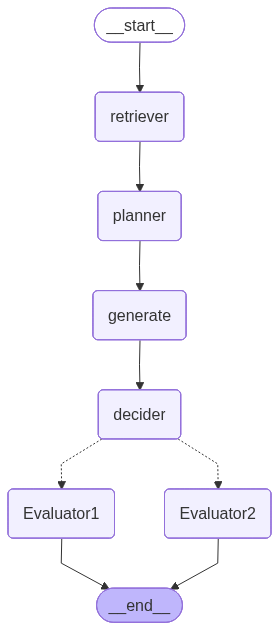

In [338]:
from IPython.display import Image

#Image(graph.get_graph().draw_png())
Image(graph.get_graph().draw_mermaid_png())


In [339]:
from IPython.display import Markdown, display

thread = {"configurable": {"thread_id": "1"}}

def print_pretty_output():
    initial_state = {
        "task": (
            "Evaluate each of the provided CVs using only the content available in the agent state. \
            Do not invent information. If any required detail is missing from the context, answer: 'The information is not available in the context.' \
            Keep the response clear, concise, and structured. \
            Use the following variables if available: {candidate_name}, {language}, {format}. \
            For each CV, provide: \
            1. Summary of the professional profile. \
            2. Main strengths and competencies. \
            3. Technical and soft skills explicitly mentioned. \
            4. Relevant experience and achievements included in the text. \
            5. Items not specified when applicable."
        ),
        "content": []
    }

    for event in graph.stream(initial_state, config=thread):
        display(Markdown(f"### Stream Event\n```\n{event}\n```"))

print_pretty_output()

🤖 LLM extracted query: 'CV evaluation, professional profile summary, candidate skills, language proficiency, CV format'
✅ Retrieved 10 chunks
📄 Sample: Technical Skills
 Programming: Python, TypeScript/Node.js, Go, Bash, C++
 LLMs: OpenAI GPT series, Llama 3, Mistral, Mixtral, Falcon, Gemma
 Toolin...


### Stream Event
```
{'retriever': {'context': ['Technical Skills\n\x7f Programming: Python, TypeScript/Node.js, Go, Bash, C++\n\x7f LLMs: OpenAI GPT series, Llama 3, Mistral, Mixtral, Falcon, Gemma\n\x7f Tooling: LangChain, LangGraph, LlamaIndex, HuggingFace Transformers\n\x7f RAG: Pinecone, Weaviate, FAISS, pgvector, hybrid search, chunking strategies\n\x7f Frameworks: PyTorch, TensorFlow, JAX, PyTorch Lightning, Accelerate\n\x7f Cloud: AWS (SageMaker, EKS, Lambda), GCP (Vertex AI), Azure ML', 'Technical Skills\n\x7f Programming: Python, C++, Go, Rust (intermediate), TypeScript\n\x7f Deep Learning: PyTorch, TensorFlow, JAX, Flax, Haiku\n\x7f LLM & RAG: GPT models, PaLM, Llama 3, Mistral, Hybrid Search, Distributed FAISS, Pinecone\n\x7f Cloud: GCP (expert), AWS, Azure, Kubernetes, Borg\n\x7f MLOps: TFX, Vertex AI, MLflow, Ray Serve, KServe', 'RAG■enhanced LLM system capable of parsing, embedding, and benchmarking resumes for HR\ndepartments.\nCertifications', 'technology companies including Google, Meta, and Microsoft. Expert in LLM architecture, retrieval\nsystems, distributed training pipelines, and high-performance inference. Proven success leading\nengineering teams to build reliable AI solutions serving millions of global users.\nEducation\nPh.D. in Machine Learning – MIT (2014–2018)\nBachelor of Science in Computer Science – Carnegie Mellon University (2010–2014)\nTechnical Skills\n\x7f Programming: Python, C++, Go, Rust (intermediate), TypeScript', '\x7f AWS Certified Machine Learning Engineer – Specialty\n\x7f Google Professional Cloud Architect\n\x7f TensorFlow Developer Certification\n\x7f Stanford Machine Learning Certificate (Andrew Ng)\nPublications\n\x7f “Hybrid Retrieval Strategies for Large■Scale RAG Systems,” 2023\n\x7f “Optimizing Transformer Inference on Edge Devices,” ICML Workshop, 2022\nAwards\n\x7f NovaMind Innovation Award (2023)\n\x7f DeepVision Employee Excellence Award (2021)\nLanguages\nEnglish (Native), Spanish (Intermediate), German (Basic)', 'Machine Learning Engineer – Microsoft Azure AI (2016–2019)\n\x7f Implemented neural ranking models for Azure Cognitive Search with measurable improvements.\n\x7f Contributed to Azure ML distributed training APIs and ONNX Runtime acceleration.\nAI Research Intern – Amazon Alexa AI (2015)\n\x7f Improved speech-to-text transformer encoder resulting in 5% accuracy gain.\nProjects\n\x7f Enterprise RAG system for large-scale search\n\x7f Multimodal LLM combining text, image, and code embeddings', 'Emily R. Stanton\nPrincipal AI Engineer & LLM Systems Architect\nContact Information\nEmail: emily.stanton.ai@example.com\nPhone: +1 (415) 555-9023\nLocation: Seattle, WA, USA\nLinkedIn: linkedin.com/in/emilystanton-LLM\nGitHub: github.com/emily-ml\nProfessional Summary\nPrincipal AI Engineer with 10+ years of experience designing large-scale AI and RAG systems at major\ntechnology companies including Google, Meta, and Microsoft. Expert in LLM architecture, retrieval', 'Modular orchestration system built with LangGraph coordinating agents for retrieval, ranking,\nreasoning, hallucination detection,\nand evaluation. Used by multiple enterprise teams.\nTechnologies: Pinecone, OpenAI API, FastAPI, LangGraph\nFloor Plan Understanding System\nFloor■plan segmentation and classification using ViT■Swin+Mask2Former pipeline for real estate\nanalytics.\nResume Intelligence Engine\nRAG■enhanced LLM system capable of parsing, embedding, and benchmarking resumes for HR', 'Retrieval-Augmented Generation (RAG) pipelines,\nand multimodal deep learning models. Expert in LLM architecture, embeddings, model compression,\nfine■tuning strategies,\nand distributed training. Passionate about designing AI agents and autonomous workflows with\nLangChain, LangGraph,\nand custom orchestration systems. Strong cross■functional collaborator with a track record of leading\nhigh■impact AI initiatives\nfrom research to production.\nEducation', '\x7f Supervised 12 engineers working on hybrid retrieval and model evaluation systems.\nSenior Machine Learning Engineer – Meta AI (2019–2022)\n\x7f Developed large-scale transformer-based relevance models for social graph ranking.\n\x7f Designed distributed FAISS indexing system handling billions of embeddings.\n\x7f Built LoRA-based fine■tuning workflows for Meta’s internal LLMs.\nMachine Learning Engineer – Microsoft Azure AI (2016–2019)'], 'content': ['Technical Skills\n\x7f Programming: Python, TypeScript/Node.js, Go, Bash, C++\n\x7f LLMs: OpenAI GPT series, Llama 3, Mistral, Mixtral, Falcon, Gemma\n\x7f Tooling: LangChain, LangGraph, LlamaIndex, HuggingFace Transformers\n\x7f RAG: Pinecone, Weaviate, FAISS, pgvector, hybrid search, chunking strategies\n\x7f Frameworks: PyTorch, TensorFlow, JAX, PyTorch Lightning, Accelerate\n\x7f Cloud: AWS (SageMaker, EKS, Lambda), GCP (Vertex AI), Azure ML', 'Technical Skills\n\x7f Programming: Python, C++, Go, Rust (intermediate), TypeScript\n\x7f Deep Learning: PyTorch, TensorFlow, JAX, Flax, Haiku\n\x7f LLM & RAG: GPT models, PaLM, Llama 3, Mistral, Hybrid Search, Distributed FAISS, Pinecone\n\x7f Cloud: GCP (expert), AWS, Azure, Kubernetes, Borg\n\x7f MLOps: TFX, Vertex AI, MLflow, Ray Serve, KServe', 'RAG■enhanced LLM system capable of parsing, embedding, and benchmarking resumes for HR\ndepartments.\nCertifications', 'technology companies including Google, Meta, and Microsoft. Expert in LLM architecture, retrieval\nsystems, distributed training pipelines, and high-performance inference. Proven success leading\nengineering teams to build reliable AI solutions serving millions of global users.\nEducation\nPh.D. in Machine Learning – MIT (2014–2018)\nBachelor of Science in Computer Science – Carnegie Mellon University (2010–2014)\nTechnical Skills\n\x7f Programming: Python, C++, Go, Rust (intermediate), TypeScript', '\x7f AWS Certified Machine Learning Engineer – Specialty\n\x7f Google Professional Cloud Architect\n\x7f TensorFlow Developer Certification\n\x7f Stanford Machine Learning Certificate (Andrew Ng)\nPublications\n\x7f “Hybrid Retrieval Strategies for Large■Scale RAG Systems,” 2023\n\x7f “Optimizing Transformer Inference on Edge Devices,” ICML Workshop, 2022\nAwards\n\x7f NovaMind Innovation Award (2023)\n\x7f DeepVision Employee Excellence Award (2021)\nLanguages\nEnglish (Native), Spanish (Intermediate), German (Basic)', 'Machine Learning Engineer – Microsoft Azure AI (2016–2019)\n\x7f Implemented neural ranking models for Azure Cognitive Search with measurable improvements.\n\x7f Contributed to Azure ML distributed training APIs and ONNX Runtime acceleration.\nAI Research Intern – Amazon Alexa AI (2015)\n\x7f Improved speech-to-text transformer encoder resulting in 5% accuracy gain.\nProjects\n\x7f Enterprise RAG system for large-scale search\n\x7f Multimodal LLM combining text, image, and code embeddings', 'Emily R. Stanton\nPrincipal AI Engineer & LLM Systems Architect\nContact Information\nEmail: emily.stanton.ai@example.com\nPhone: +1 (415) 555-9023\nLocation: Seattle, WA, USA\nLinkedIn: linkedin.com/in/emilystanton-LLM\nGitHub: github.com/emily-ml\nProfessional Summary\nPrincipal AI Engineer with 10+ years of experience designing large-scale AI and RAG systems at major\ntechnology companies including Google, Meta, and Microsoft. Expert in LLM architecture, retrieval', 'Modular orchestration system built with LangGraph coordinating agents for retrieval, ranking,\nreasoning, hallucination detection,\nand evaluation. Used by multiple enterprise teams.\nTechnologies: Pinecone, OpenAI API, FastAPI, LangGraph\nFloor Plan Understanding System\nFloor■plan segmentation and classification using ViT■Swin+Mask2Former pipeline for real estate\nanalytics.\nResume Intelligence Engine\nRAG■enhanced LLM system capable of parsing, embedding, and benchmarking resumes for HR', 'Retrieval-Augmented Generation (RAG) pipelines,\nand multimodal deep learning models. Expert in LLM architecture, embeddings, model compression,\nfine■tuning strategies,\nand distributed training. Passionate about designing AI agents and autonomous workflows with\nLangChain, LangGraph,\nand custom orchestration systems. Strong cross■functional collaborator with a track record of leading\nhigh■impact AI initiatives\nfrom research to production.\nEducation', '\x7f Supervised 12 engineers working on hybrid retrieval and model evaluation systems.\nSenior Machine Learning Engineer – Meta AI (2019–2022)\n\x7f Developed large-scale transformer-based relevance models for social graph ranking.\n\x7f Designed distributed FAISS indexing system handling billions of embeddings.\n\x7f Built LoRA-based fine■tuning workflows for Meta’s internal LLMs.\nMachine Learning Engineer – Microsoft Azure AI (2016–2019)']}}
```

### Stream Event
```
{'planner': {'plan': "1. **Summary of the professional profile**:  \n   {candidate_name} is a Principal AI Engineer and LLM Systems Architect with over 10 years of experience in designing large-scale AI and RAG systems at major technology companies, including Google, Meta, and Microsoft. \n\n2. **Main strengths and competencies**:  \n   - Expertise in LLM architecture and retrieval systems.  \n   - Proven leadership in engineering teams and high-impact AI initiatives.  \n   - Strong cross-functional collaboration skills.\n\n3. **Technical and soft skills explicitly mentioned**:  \n   - **Technical Skills**: Python, TypeScript, Go, C++, Rust (intermediate), PyTorch, TensorFlow, JAX, Flax, Haiku, GPT models, PaLM, Llama 3, Hybrid Search, Distributed FAISS, Pinecone, GCP (expert), AWS, Azure, Kubernetes, TFX, Vertex AI, MLflow, Ray Serve, KServe.  \n   - **Soft Skills**: Leadership, collaboration, communication.\n\n4. **Relevant experience and achievements included in the text**:  \n   - Developed neural ranking models and contributed to Azure ML distributed training APIs at Microsoft Azure AI.  \n   - Improved speech-to-text transformer encoder at Amazon Alexa AI.  \n   - Supervised 12 engineers on hybrid retrieval and model evaluation systems.  \n   - Received the NovaMind Innovation Award (2023) and DeepVision Employee Excellence Award (2021).\n\n5. **Items not specified when applicable**:  \n   - Specific details on the number of projects led or the impact of the projects are not available.  \n   - The information regarding specific roles or responsibilities at Google and Meta is not available.  \n   - The information is not available in the context regarding the candidate's certifications, publications, and languages spoken."}}
```

### Stream Event
```
{'generate': {'answer': '1. **Summary of the professional profile:**  \n   Emily R. Stanton is a Principal AI Engineer and LLM Systems Architect with over 10 years of experience in designing large-scale AI and RAG systems at major technology companies, including Google, Meta, and Microsoft. She is an expert in LLM architecture and retrieval systems, with a strong focus on leading high-impact AI initiatives from research to production.\n\n2. **Main strengths and competencies:**  \n   - Expertise in LLM architecture and retrieval systems  \n   - Proven leadership in engineering teams  \n   - Strong cross-functional collaboration skills  \n   - Passion for designing AI agents and autonomous workflows  \n\n3. **Technical and soft skills explicitly mentioned:**  \n   - **Technical Skills:**  \n     - Programming: Python, TypeScript/Node.js, Go, Bash, C++  \n     - Deep Learning: PyTorch, TensorFlow, JAX  \n     - LLMs: OpenAI GPT series, Llama 3, Mistral, etc.  \n     - RAG: Pinecone, Weaviate, FAISS, etc.  \n     - Cloud: AWS, GCP, Azure ML  \n     - MLOps: TFX, Vertex AI, MLflow  \n   - **Soft Skills:**  \n     - Leadership  \n     - Collaboration  \n\n4. **Relevant experience and achievements included in the text:**  \n   - **Professional Experience:**  \n     - Senior Machine Learning Engineer at Meta AI (2019–2022): Developed transformer-based relevance models and designed distributed FAISS indexing systems.  \n     - Machine Learning Engineer at Microsoft Azure AI (2016–2019): Implemented neural ranking models and contributed to distributed training APIs.  \n     - AI Research Intern at Amazon Alexa AI (2015): Improved speech-to-text transformer encoder.  \n   - **Projects:**  \n     - Modular orchestration system with LangGraph  \n     - Floor Plan Understanding System  \n     - Resume Intelligence Engine  \n   - **Awards:**  \n     - NovaMind Innovation Award (2023)  \n     - DeepVision Employee Excellence Award (2021)  \n   - **Publications:**  \n     - “Hybrid Retrieval Strategies for Large-Scale RAG Systems,” 2023  \n     - “Optimizing Transformer Inference on Edge Devices,” ICML Workshop, 2022  \n\n5. **Items not specified when applicable:**  \n   - Specific details about the impact of projects or systems developed  \n   - Metrics or quantifiable results from her roles  \n   - Additional certifications beyond those listed  \n   - Languages spoken beyond English, Spanish, and German'}}
```

🤖 LLM response (741 chars)
✅ JSON parsed (direct)
👤 Detected: Emily R. Stanton
💼 Role: AI Engineer
🔀 Routing to: Evaluator1
📋 Reason: Candidate's name matches the known AI-focused candidate list, and their seniority and role align with the technical routing for Evaluator1.
📍 Routing function called, going to: Evaluator1


### Stream Event
```
{'decider': {'next': 'Evaluator1', 'decider': 'Evaluator1', 'detected_name': 'Emily R. Stanton'}}
```

✅ Evaluator1 Queries: queries=["Summary of Emily R. Stanton's professional profile", 'Main strengths and competencies of Emily R. Stanton', 'Technical and soft skills of Emily R. Stanton', 'Relevant experience and achievements of Emily R. Stanton', 'Items not specified for Emily R. Stanton']
📄 Answer: Emily R. Stanton is a Principal AI Engineer and LLM Systems Architect with over 10 years of experience in designing large-scale AI and retrieval-augmented generation (RAG) systems at major technology companies such as Google, Meta, and Microsoft. She is an expert in LLM architecture, retrieval systems, distributed training pipelines, and high-performance inference. Emily has a proven track record of leading engineering teams to develop reliable AI solutions that serve millions of users globally. She holds a Ph.D. in Machine Learning from MIT and a Bachelor of Science in Computer Science from Carnegie Mellon University. Her technical skills include programming in Python, C++, Go, and Rust,

### Stream Event
```
{'Evaluator1': {'content': ['Emily R. Stanton is a Principal AI Engineer and LLM Systems Architect with over 10 years of experience in designing large-scale AI and retrieval-augmented generation (RAG) systems at major technology companies such as Google, Meta, and Microsoft. She is an expert in LLM architecture, retrieval systems, distributed training pipelines, and high-performance inference. Emily has a proven track record of leading engineering teams to develop reliable AI solutions that serve millions of users globally. She holds a Ph.D. in Machine Learning from MIT and a Bachelor of Science in Computer Science from Carnegie Mellon University. Her technical skills include programming in Python, C++, Go, and Rust, and she holds several certifications, including AWS Certified Machine Learning Engineer and Google Professional Cloud Architect. Emily has published research on hybrid retrieval strategies and optimizing transformer inference, and she has received awards for innovation and excellence in her field. She is fluent in English, with intermediate proficiency in Spanish and basic knowledge of German.', "Emily R. Stanton's main strengths and competencies include:\n\n1. **Expertise in AI and LLM Systems**: Over 10 years of experience in designing large-scale AI and retrieval-augmented generation (RAG) systems.\n2. **Technical Skills**: Proficient in programming languages such as Python, C++, Go, and Rust, with intermediate knowledge in TypeScript.\n3. **Cloud and Machine Learning Certifications**: Holds certifications as an AWS Certified Machine Learning Engineer and a Google Professional Cloud Architect, along with a TensorFlow Developer Certification.\n4. **Leadership**: Proven success in leading engineering teams to develop reliable AI solutions that serve millions of users globally.\n5. **Research and Publications**: Authored publications on hybrid retrieval strategies and optimizing transformer inference, showcasing a strong research background.\n6. **Education**: Holds a Ph.D. in Machine Learning from MIT and a Bachelor of Science in Computer Science from Carnegie Mellon University.\n7. **Awards and Recognition**: Recipient of the NovaMind Innovation Award and the DeepVision Employee Excellence Award, indicating recognition for her contributions in the field. \n8. **Multilingual**: Fluent in English, with intermediate Spanish and basic German skills.", "**Technical Skills:**\n- **Programming Languages:** Python, TypeScript/Node.js, Go, Bash, C++, Rust (intermediate)\n- **LLMs (Large Language Models):** OpenAI GPT series, Llama 3, Mistral, Mixtral, Falcon, Gemma, PaLM\n- **Tooling:** LangChain, LangGraph, LlamaIndex, HuggingFace Transformers\n- **RAG (Retrieval-Augmented Generation):** Pinecone, Weaviate, FAISS, pgvector, hybrid search, chunking strategies, Distributed FAISS\n- **Frameworks:** PyTorch, TensorFlow, JAX, PyTorch Lightning, Accelerate, Flax, Haiku\n- **Cloud Platforms:** AWS (SageMaker, EKS, Lambda), GCP (Vertex AI), Azure ML, Kubernetes, Borg\n- **MLOps:** TFX, Vertex AI, MLflow, Ray Serve, KServe\n\n**Soft Skills:**\nThe provided context does not specify any soft skills. Therefore, I don't have information on Emily R. Stanton's soft skills.", 'Emily R. Stanton has over 10 years of experience as a Principal AI Engineer, specializing in designing large-scale AI and retrieval-augmented generation (RAG) systems at major technology companies such as Google, Meta, and Microsoft. She is an expert in LLM architecture, retrieval systems, distributed training pipelines, and high-performance inference. \n\nHer achievements include leading engineering teams to build reliable AI solutions that serve millions of global users. She has successfully transitioned high-impact AI initiatives from research to production. \n\nIn terms of education, she holds a Master of Science in Artificial Intelligence from Stanford University and a Ph.D. in Machine Learning from MIT, along with a Bachelor of Science in Computer Engineering from the University of Texas at Austin and a Bachelor of Science in Computer Science from Carnegie Mellon University.', "I don't know."]}}
```